In [2]:
%pip install -r ../../requirements.txt

import pandas as pd

Note: you may need to restart the kernel to use updated packages.


In [3]:
toronto_data = pd.read_csv('../data/toronto_real_estate_public_area.csv')

In [4]:
toronto_data.head(3)

,property_id,period,home_type_bucket,status,last_status,home_type,price,list_price,sold_price,list_date,neighbourhood,latitude,longitude,bedrooms,bedrooms_plus,bathrooms,brokerage,images_count,estimated_area_sqft
0,1,sale,CONDO,ACTIVE,PRICE_CHANGE,CONDO,388000.0,388000.0,NaN,2026-04-12T13:29:08.000Z,Waterfront Communities The Island,43.648879,-79.388044,1.0,NaN,1.0,HC REALTY GROUP INC.,46,350.0
1,2,sale,CONDO,ACTIVE,NEW,CONDO,385000.0,385000.0,NaN,2026-05-28T11:31:44.000Z,Moss Park,43.653313,-79.359882,NaN,NaN,1.0,BAKER REAL ESTATE INCORPORATED,24,350.0
2,3,sale,CONDO,ACTIVE,NEW,CONDO,299000.0,299000.0,NaN,2026-06-09T10:35:34.000Z,Church-Yonge Corridor,43.657375,-79.374087,NaN,NaN,1.0,SUPERSTARS REALTY LTD.,25,350.0


In [5]:
# We'll be using sold_price as the target for this model, and won't be using price or list_price as features.

toronto_data = toronto_data.drop(columns=['property_id', 'period', 'brokerage', 'home_type_bucket', 'price', 'list_price', 'images_count','status'])

In [6]:
toronto_data

,last_status,home_type,sold_price,list_date,neighbourhood,latitude,longitude,bedrooms,bedrooms_plus,bathrooms,estimated_area_sqft
0,PRICE_CHANGE,CONDO,NaN,2026-04-12T13:29:08.000Z,Waterfront Communities The Island,43.648879,-79.388044,1.0,NaN,1.0,350.0
1,NEW,CONDO,NaN,2026-05-28T11:31:44.000Z,Moss Park,43.653313,-79.359882,NaN,NaN,1.0,350.0
2,NEW,CONDO,NaN,2026-06-09T10:35:34.000Z,Church-Yonge Corridor,43.657375,-79.374087,NaN,NaN,1.0,350.0
3,NEW,CONDO,NaN,2026-06-20T09:57:05.000Z,Bay Street Corridor,43.661136,-79.385605,1.0,NaN,1.0,650.0
4,NEW,CONDO,NaN,2026-06-03T21:38:51.000Z,South Riverdale,43.657640,-79.350917,1.0,NaN,1.0,550.0
...,...,...,...,...,...,...,...,...,...,...,...
9699,SOLD,CONDO,555000.0,2024-03-15T16:55:50.000Z,Waterfront Communities C1,43.645958,-79.389873,1.0,1.0,1.0,550.0
9700,SOLD,CONDO,585000.0,2024-05-10T16:13:24.000Z,Little Portugal,43.642018,-79.423509,2.0,NaN,2.0,550.0
9701,SOLD,CONDO,600000.0,2024-05-15T16:08:20.000Z,Clairlea Birchmount,43.716540,-79.284514,2.0,NaN,2.0,950.0
9702,SOLD,CONDO,595000.0,2024-04-01T16:00:47.000Z,Moss Park,43.656969,-79.374122,1.0,1.0,1.0,550.0


In [7]:
tud = toronto_data['sold_price'].isnull().sum()
tud

np.int64(3244)

In [8]:
toronto_data.isnull().sum()

last_status               0
home_type                 0
sold_price             3244
list_date                 0
neighbourhood             1
latitude                  0
longitude                 0
bedrooms                290
bedrooms_plus          5460
bathrooms                50
estimated_area_sqft     162
dtype: int64

In [12]:
toronto_data['locality'].isnull().sum()

np.int64(1)

In [11]:
# Renamed column to locality after normalization

toronto_data['locality'] = (
    toronto_data['neighbourhood']
    .dropna()
    .str.lower()
    .str.replace(r'^[a-z0-9]+ - ', '', regex=True)
    .str.replace(r'[-]', ' ', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

In [132]:
len(toronto_data['locality'].unique())

131

In [123]:
(toronto_data['locality'].value_counts()).sum()

np.int64(9703)

In [140]:
toronto_data = toronto_data.drop(columns=['neighbourhood'])

In [138]:
toronto_data = toronto_data.rename(columns={'bedrooms' : 'beds', 'bedrooms_plus' : 'beds_plus', 'bathrooms': 'baths', 'estimated_area_sqft': 'area'})

In [153]:
(toronto_data['locality'].value_counts() <= 1).sum()

np.int64(21)

In [155]:
toronto_data['price_per_sqft'] = toronto_data['sold_price'] / toronto_data['area']

/var/folders/qf/wwtn7pd17xzb9r_bmy7p58z80000gn/T/ipykernel_29846/640035442.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  toronto_data['price_per_sqft'] = toronto_data['sold_price'] / toronto_data['area']


In [157]:
toronto_data.tail(3)

,last_status,home_type,sold_price,list_date,latitude,longitude,beds,beds_plus,baths,area,locality,price_per_sqft
9701,SOLD,CONDO,600000.0,2024-05-15T16:08:20.000Z,43.716540,-79.284514,2.0,NaN,2.0,950.0,clairlea birchmount,631.578947
9702,SOLD,CONDO,595000.0,2024-04-01T16:00:47.000Z,43.656969,-79.374122,1.0,1.0,1.0,550.0,moss park,1081.818182
9703,SOLD,CONDO,550500.0,2024-05-04T15:54:48.000Z,43.640144,-79.423917,2.0,NaN,2.0,750.0,south parkdale,734.000000


In [159]:
locality_stats = toronto_data.groupby('locality')['locality'].agg('count').sort_values(ascending=False)
locality_stats

locality
waterfront communities c1            859
waterfront communities the island    704
church yonge corridor                665
bay street corridor                  511
niagara                              462
                                    ... 
east york                              1
dorset park                            1
cliffcrest                             1
don valley village                     1
danforth village east york             1
Name: locality, Length: 130, dtype: int64

In [163]:
locality_less_than_2 = locality_stats[locality_stats <= 1]
locality_less_than_2

locality
humberlea pelmo park w5       1
hillcrest village             1
alderwood                     1
morningside                   1
woodbine lumsden              1
milliken                      1
bayview village               1
bathurst manor                1
highland creek                1
crescent town                 1
north j                       1
black creek                   1
west hill                     1
carleton place                1
port perry                    1
tudor ward                    1
east york                     1
dorset park                   1
cliffcrest                    1
don valley village            1
danforth village east york    1
Name: locality, dtype: int64

In [165]:
toronto_data.locality = toronto_data.locality.apply(lambda x: 'other' if x in locality_less_than_2 else x)

In [182]:
len(toronto_data[toronto_data.area / toronto_data.beds < 300])

174

In [176]:
toronto_data.groupby('beds')['area'].describe()

,count,mean,std,min,25%,50%,75%,max
beds,,,,,,,,
1.0,3048.0,611.960302,184.619649,350.0,550.0,650.0,650.0,5000.0
2.0,3226.0,1057.106634,407.265140,350.0,750.0,950.0,1100.0,3874.0
3.0,1523.0,1591.493106,628.313578,700.0,1300.0,1300.0,1750.0,6000.0
4.0,941.0,2496.840595,881.951719,700.0,1750.0,2250.0,2750.0,5000.0
5.0,343.0,3012.314869,1101.158165,700.0,2250.0,2750.0,4250.0,6548.0
6.0,113.0,3434.955752,1106.250201,700.0,2250.0,3250.0,4250.0,5200.0
7.0,31.0,3280.645161,1276.432360,700.0,2250.0,2750.0,4250.0,5000.0
8.0,22.0,3536.363636,1004.416654,1300.0,2750.0,4125.0,4250.0,5000.0
9.0,6.0,3833.333333,664.580068,2750.0,3500.0,4250.0,4250.0,4250.0


In [183]:
ds = toronto_data[~(toronto_data.area / toronto_data.beds < 300)]

In [189]:
ds.baths.isna().sum()

np.int64(50)

In [193]:
# Removed rows with no baths
ds_1 = ds[~(ds.baths.isna())]

In [194]:
ds_1.baths.isna().sum()

np.int64(0)

Text(0, 0.5, 'Count')

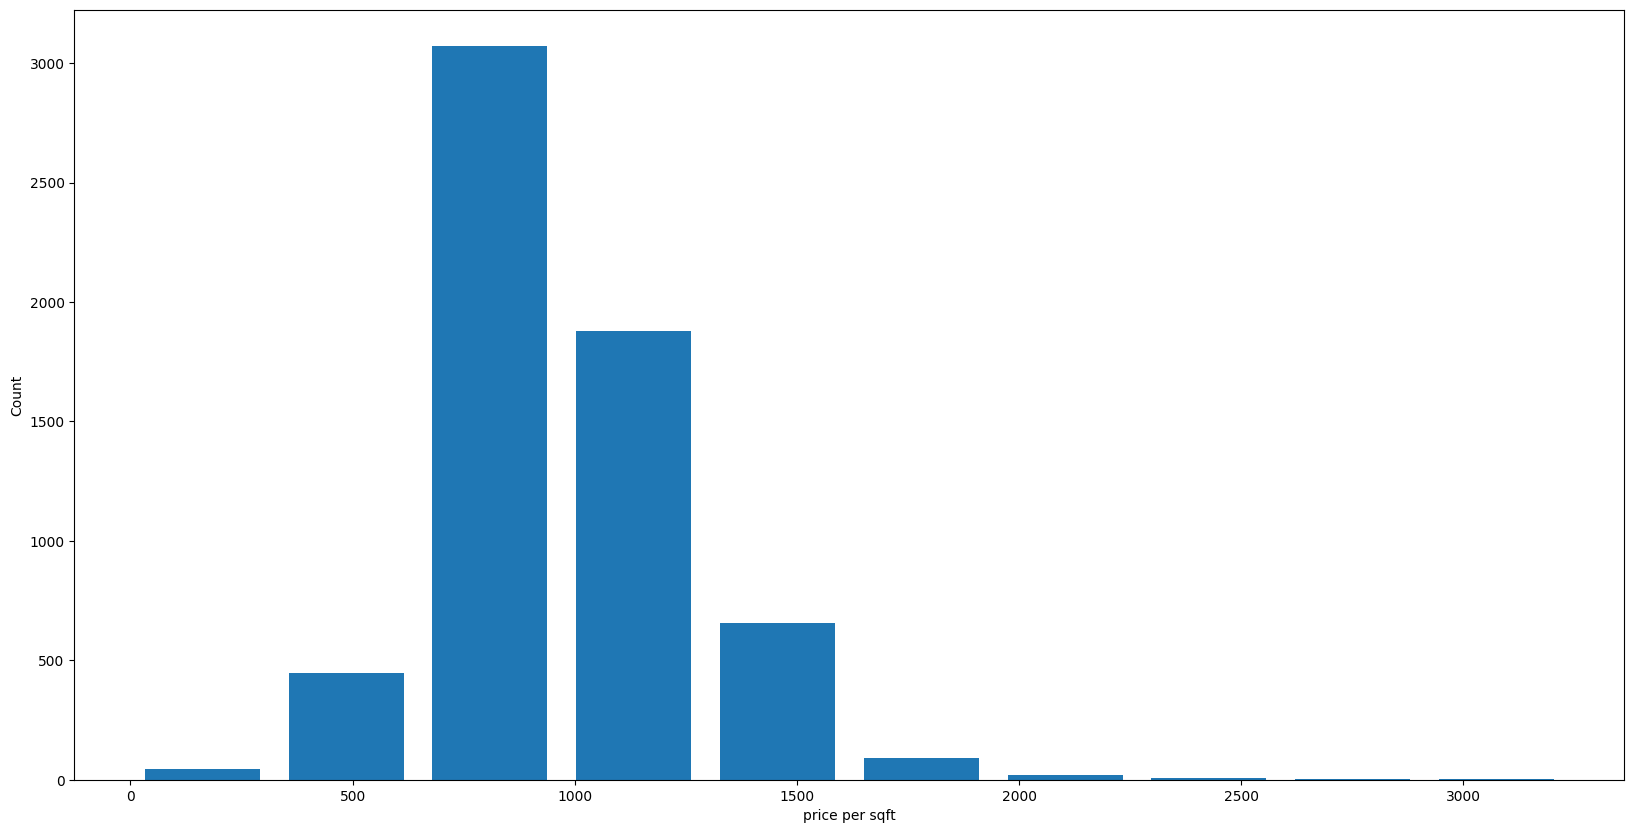

In [199]:
import matplotlib
from matplotlib import pyplot as plt

matplotlib.rcParams['figure.figsize'] = (20, 10)
plt.hist(ds_1.price_per_sqft, rwidth=0.8)
plt.xlabel("price per sqft")
plt.ylabel("Count")

In [211]:
ds_1.baths.unique()

array([1., 2., 3., 5., 4., 8., 6., 9., 7.])

In [205]:
ds_1[ds_1.baths>10]

,last_status,home_type,sold_price,list_date,latitude,longitude,beds,beds_plus,baths,area,locality,price_per_sqft
2482,NEW,CONDO,NaN,2026-06-12T11:19:27.000Z,43.663307,-79.371692,NaN,NaN,12.0,2665.0,moss park,NaN
2563,NEW,CONDO,NaN,2026-06-16T00:55:03.000Z,43.650792,-79.417718,NaN,NaN,12.0,7700.0,trinity bellwoods,NaN
2586,NEW,CONDO,NaN,2025-11-15T19:22:13.000Z,43.660120,-79.372828,NaN,NaN,22.0,7841.0,moss park,NaN
2626,NEW,CONDO,NaN,2026-04-01T15:20:02.000Z,43.706289,-79.294548,NaN,NaN,12.0,NaN,clairlea birchmount,NaN
2633,NEW,CONDO,NaN,2026-06-12T09:01:43.000Z,43.671117,-79.297995,NaN,NaN,11.0,11232.0,the beaches,NaN
3197,NEW,HOUSE,NaN,2026-05-01T19:30:25.000Z,43.678844,-79.406816,6.0,2.0,11.0,5000.0,casa loma,NaN
3284,NEW,DUPLEX_TRIPLEX_FOURPLEX,NaN,2026-05-05T00:22:59.000Z,43.674409,-79.432568,4.0,4.0,11.0,3250.0,wychwood,NaN


In [206]:
ds_1 = ds_1[ds_1.baths < 10]

In [210]:
ds_1

,last_status,home_type,sold_price,list_date,latitude,longitude,beds,beds_plus,baths,area,locality,price_per_sqft
0,PRICE_CHANGE,CONDO,NaN,2026-04-12T13:29:08.000Z,43.648879,-79.388044,1.0,NaN,1.0,350.0,waterfront communities the island,NaN
1,NEW,CONDO,NaN,2026-05-28T11:31:44.000Z,43.653313,-79.359882,NaN,NaN,1.0,350.0,moss park,NaN
2,NEW,CONDO,NaN,2026-06-09T10:35:34.000Z,43.657375,-79.374087,NaN,NaN,1.0,350.0,church yonge corridor,NaN
3,NEW,CONDO,NaN,2026-06-20T09:57:05.000Z,43.661136,-79.385605,1.0,NaN,1.0,650.0,bay street corridor,NaN
4,NEW,CONDO,NaN,2026-06-03T21:38:51.000Z,43.657640,-79.350917,1.0,NaN,1.0,550.0,south riverdale,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
9698,SOLD,CONDO,517500.0,2024-04-08T17:04:29.000Z,43.652995,-79.468987,1.0,NaN,1.0,350.0,high park north,1478.571429
9699,SOLD,CONDO,555000.0,2024-03-15T16:55:50.000Z,43.645958,-79.389873,1.0,1.0,1.0,550.0,waterfront communities c1,1009.090909
9701,SOLD,CONDO,600000.0,2024-05-15T16:08:20.000Z,43.716540,-79.284514,2.0,NaN,2.0,950.0,clairlea birchmount,631.578947
9702,SOLD,CONDO,595000.0,2024-04-01T16:00:47.000Z,43.656969,-79.374122,1.0,1.0,1.0,550.0,moss park,1081.818182


In [212]:
toronto_ds = ds_1.drop(columns=['price_per_sqft'])

In [213]:
toronto_ds

,last_status,home_type,sold_price,list_date,latitude,longitude,beds,beds_plus,baths,area,locality
0,PRICE_CHANGE,CONDO,NaN,2026-04-12T13:29:08.000Z,43.648879,-79.388044,1.0,NaN,1.0,350.0,waterfront communities the island
1,NEW,CONDO,NaN,2026-05-28T11:31:44.000Z,43.653313,-79.359882,NaN,NaN,1.0,350.0,moss park
2,NEW,CONDO,NaN,2026-06-09T10:35:34.000Z,43.657375,-79.374087,NaN,NaN,1.0,350.0,church yonge corridor
3,NEW,CONDO,NaN,2026-06-20T09:57:05.000Z,43.661136,-79.385605,1.0,NaN,1.0,650.0,bay street corridor
4,NEW,CONDO,NaN,2026-06-03T21:38:51.000Z,43.657640,-79.350917,1.0,NaN,1.0,550.0,south riverdale
...,...,...,...,...,...,...,...,...,...,...,...
9698,SOLD,CONDO,517500.0,2024-04-08T17:04:29.000Z,43.652995,-79.468987,1.0,NaN,1.0,350.0,high park north
9699,SOLD,CONDO,555000.0,2024-03-15T16:55:50.000Z,43.645958,-79.389873,1.0,1.0,1.0,550.0,waterfront communities c1
9701,SOLD,CONDO,600000.0,2024-05-15T16:08:20.000Z,43.716540,-79.284514,2.0,NaN,2.0,950.0,clairlea birchmount
9702,SOLD,CONDO,595000.0,2024-04-01T16:00:47.000Z,43.656969,-79.374122,1.0,1.0,1.0,550.0,moss park


In [1]:
toronto_ds['list_date'] = pd.to_datetime(toronto_ds['list_date'])

NameError: name 'pd' is not defined